<img src="logos/logo_Facyt.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Pokemon - Modeling and Model Selection

> **Purpose:** turn technical evidence into a **defensible and reproducible** model decision.

This notebook develops the modeling phase to predict Pokemon battle winners.

It builds on the validated artifacts from Data Preparation to preserve reproducibility, prevent leakage, and ensure comparability across models.

---

## Phase Objectives

1. Establish a quantitative baseline (Dummy, Logistic, Tree).
2. Compare higher-capacity candidates under the same validation protocol.
3. Optimize hyperparameters with Optuna using F1 as the target metric.
4. Select the final model with explicit and auditable criteria.
5. Evaluate once on hold-out test data and discuss errors.
6. Persist artifacts and technical evidence for traceability.

## Questions This Notebook Answers

1. Is the improvement of complex models over baselines real or only apparent?
2. What does tuning add, and how much does it actually improve performance?
3. Does the selected model generalize to test data consistently with CV?
4. What kinds of errors does it make, and how does that change with thresholds?
5. Which variables drive predictions, and are they consistent with EDA?

## Quick Reading Guide

> **Document map:** each block supports a concrete model-selection decision.

1. **Experiment Validity and Technical Contract**  
Experimental setup, artifact loading, and structural validation.

2. **Initial Model Comparison**  
Baseline and candidate definition, CV evaluation, and pre-tuning ranking.

3. **Optimization and Selection**  
Optuna tuning, comparative synthesis, and formal final-selection rule.

4. **Generalization and Diagnostics**  
Final test evaluation, confusion matrix, and threshold analysis.

5. **Interpretability and Governance Closure**  
Feature importance, artifact persistence, conclusions, and limitations.

## Methodological Framework and Decision Criteria

This notebook follows a methodology focused on **statistical validity**, **experiment comparability**, and **decision traceability**.

### Applied Methodological Principles

- Reuse exactly the preprocessing pipeline generated in Data Preparation.
- Keep test data fully isolated until final evaluation.
- Compare baseline models first, then higher-capacity models.
- Apply the same stratified cross-validation scheme to all models.
- Log results and artifacts for reproducibility and auditing.

### Continuity with EDA and Data Preparation

- EDA showed the strongest signals are relative (especially diff_speed and diff_stats_total).
- Data Preparation removed variables with leakage risk (Winner, WinRate, Wins, n_combats).
- The split was designed with matchup-dependence criteria to reduce train-test contamination.
- Modeling starts from these technical contracts without rebuilding data from scratch.

### Model Families

**Baseline models (reference):**
- Dummy Classifier.
- Logistic Regression.
- Decision Tree.

**Candidate models (higher capacity):**
- Random Forest.
- HistGradientBoosting.

### Evaluation Metrics

**Primary metric:**
- F1-score (balance between precision and recall).

**Complementary metrics:**
- Accuracy.
- Balanced Accuracy.
- ROC-AUC.

### Promotion Rule

Only models that meet all criteria move to tuning:
- consistently outperform baselines on CV-F1,
- remain coherent on complementary metrics,
- justify additional complexity versus computational cost.

## General Structure of a Scikit-Learn Model

> **Operating pattern:** define, train, predict, and (optionally) estimate probabilities.

```python
from sklearn.some_module import SomeModel

# 1) Define the estimator with hyperparameters
model = SomeModel(param1=..., param2=...)

# 2) Train
model.fit(X_train, y_train)

# 3) Predict
y_pred = model.predict(X_test)

# 4) Optional: probabilities
y_proba = model.predict_proba(X_test)[:, 1]
```

In this notebook, that pattern is always encapsulated in a preprocessing + model pipeline.

This avoids discrepancies between training and inference, reduces information leakage, and makes every experiment comparable.

## Imports and Configuration

> **Experimental contract:** same rules for all models.

**What is fixed:**
- random seed for reproducibility,
- stratified cross-validation,
- shared metric set,
- report and figure output paths.

**What this design avoids:**
- comparing models under different protocols,
- non-reproducible results across runs,
- decisions based on non-homogeneous metrics.

**What this enables:**
- fair comparison among baselines, candidates, and tuned models,
- full result traceability,
- a defensible methodological closure for presentation.

In [8]:
from __future__ import annotations

from pathlib import Path
import json
import warnings
import importlib

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

try:
    optuna = importlib.import_module("optuna")
except ModuleNotFoundError as exc:
    raise ImportError(
        "Optuna is required for this notebook. Install it with: pip install optuna"
    ) from exc

RANDOM_STATE = 29
N_SPLITS = 5
OPTUNA_TRIALS = 30

ARTIFACTS_DIR = Path("../artifacts")
REPORTS_DIR = Path("../reports")
FIG_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CV = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

def densify_if_sparse(x):
    """Return dense array only when the input matrix is sparse."""
    return x.toarray() if sparse.issparse(x) else x


DENSIFY_IF_NEEDED = FunctionTransformer(
    densify_if_sparse,
    validate=False,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

### Imports and Configuration Conclusion

The setup defines a single experimental framework: same metrics, same cross-validation strategy, and same seeds.

> **Implication:** any observed performance difference is interpreted as predictive-capacity difference, not a configuration artifact.

## Loading Prepared Artifacts

This section loads only artifacts persisted by Data Preparation:
- train/test split,
- preprocessing pipeline,
- feature manifest.

**Why this is done this way:**
- avoids manual reconstructions that introduce inconsistencies,
- preserves anti-leakage guarantees,
- ensures modeling and inference use the same transformation logic.

**What is validated next:**
- train/test shapes,
- target consistency,
- feature-schema coherence.

In [9]:
feature_manifest_path = ARTIFACTS_DIR / "feature_manifest_pokemon.json"
preprocess_pipeline_path = ARTIFACTS_DIR / "preprocess_pipeline_pokemon.joblib"
split_data_path = ARTIFACTS_DIR / "split_data_pokemon.joblib"

if not feature_manifest_path.exists():
    raise FileNotFoundError(f"Missing artifact: {feature_manifest_path}")
if not preprocess_pipeline_path.exists():
    raise FileNotFoundError(f"Missing artifact: {preprocess_pipeline_path}")
if not split_data_path.exists():
    raise FileNotFoundError(f"Missing artifact: {split_data_path}")

feature_manifest = json.loads(feature_manifest_path.read_text(encoding="utf-8"))
preprocess_pipeline = joblib.load(preprocess_pipeline_path)
X_train, X_test, y_train, y_test = joblib.load(split_data_path)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target mean:", float(y_train.mean()))
print("Test target mean:", float(y_test.mean()))
print("Target column:", feature_manifest.get("target"))

Train shape: (38429, 54)
Test shape: (9619, 54)
Train target mean: 0.4717010590959952
Test target mean: 0.47271026094188584
Target column: first_wins


In [10]:
assert set(pd.Series(y_train).dropna().unique()).issubset({0, 1}), "y_train must be binary"
assert set(pd.Series(y_test).dropna().unique()).issubset({0, 1}), "y_test must be binary"
assert list(X_train.columns) == list(X_test.columns), "Train and test feature columns must match"

print("Binary target checks: OK")
print("Column alignment checks: OK")
print("Feature count:", X_train.shape[1])
print("Example features:", X_train.columns[:10].tolist())

Binary target checks: OK
Column alignment checks: OK
Feature count: 54
Example features: ['first_HP', 'first_Attack', 'first_Defense', 'first_Sp. Atk', 'first_Sp. Def', 'first_Speed', 'first_stats_total', 'first_Type 1', 'first_Type 2', 'first_Generation']


### Structural Validation Conclusion

Validation confirms three critical conditions before training:
- correct binary target,
- same feature-column structure between train and test,
- schema ready to run CV and tuning without structural failures.

> **Methodological reading:** this reduces the risk of silent errors and spurious results.

**Derived decision:** the dataset is approved for model comparison under a controlled protocol.

## Pipeline Helper Functions

> **Goal:** standardize how each model is trained and evaluated.

This section defines utilities that enforce consistent training and evaluation.

**Technical goals:**
- build homogeneous pipelines for all models,
- densify only when the estimator requires dense input,
- return CV metrics in a common structure for fair comparison.

**Practical importance:**
- avoids different preprocessing paths across models,
- resolves format incompatibilities without breaking traceability,
- enables comparable and serializable results.

In [11]:
def make_model_pipeline(preprocess, model):
    """Build a consistent pipeline and densify features only for models that require dense input."""
    steps = [("preprocess", preprocess)]

    if isinstance(model, HistGradientBoostingClassifier):
        steps.append(("to_dense", DENSIFY_IF_NEEDED))

    steps.append(("model", model))
    return Pipeline(steps=steps)


def evaluate_model_cv(model_name, preprocess, model, X, y):
    """Evaluate one model with stratified CV and return mean metrics."""
    model_pipeline = make_model_pipeline(preprocess, model)

    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X,
        y=y,
        cv=CV,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False,
    )

    return {
        "model": model_name,
        "cv_accuracy_mean": float(np.mean(cv_result["test_accuracy"])),
        "cv_balanced_accuracy_mean": float(np.mean(cv_result["test_balanced_accuracy"])),
        "cv_f1_mean": float(np.mean(cv_result["test_f1"])),
        "cv_roc_auc_mean": float(np.mean(cv_result["test_roc_auc"])),
    }

### Evaluation Utilities Conclusion

The utilities establish a single training and evaluation contract for all estimators.

**What they solve:**
- methodological consistency in CV and metrics,
- technical compatibility between sparse preprocessing and models requiring dense input,
- consistency between experimentation and persisted pipelines.

> **Operational conclusion:** model comparison is reliable because all models follow the same transformation and evaluation path.

## Full Modeling Pipeline (Visible)

> **Key idea:** we do not train isolated models here; we train a reproducible **system**.

Following the template, every experiment uses the same skeleton:

- **`preprocess`**: applies transformations inherited from Data Preparation.
- **`to_dense`** *(conditional)*: appears only when the estimator needs dense input.
- **`model`**: final estimator that learns the decision boundary.

---

**Why this matters:**
- guarantees *coherence* between training and inference,
- avoids parallel paths that introduce bias,
- makes model comparison **fair and auditable**.

The next cell prints two real pipelines so the architecture remains explicit in the document.

In [12]:
from sklearn import set_config
from IPython.display import display

if "make_model_pipeline" not in globals() or "preprocess_pipeline" not in globals():
    print("Run the setup, data-loading, and helper-function cells first to visualize the pipeline.")
else:
    # Render sklearn objects as diagrams in notebook output.
    set_config(display="diagram")

    pipeline_preview_lr = make_model_pipeline(
        preprocess_pipeline,
        LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    )

    pipeline_preview_hgb = make_model_pipeline(
        preprocess_pipeline,
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    )

    print("Pipeline (diagram) - Logistic Regression")
    display(pipeline_preview_lr)

    print("\nPipeline (diagram) - HistGradientBoosting")
    display(pipeline_preview_hgb)

    rows = []
    for pipeline_name, pipe in [
        ("logistic_regression", pipeline_preview_lr),
        ("hist_gradient_boosting", pipeline_preview_hgb),
    ]:
        for step_name, step_obj in pipe.named_steps.items():
            rows.append(
                {
                    "pipeline": pipeline_name,
                    "step": step_name,
                    "object_type": type(step_obj).__name__,
                    "details": "",
                }
            )

            # Show preprocess internals in compact form to avoid huge/truncated outputs.
            if step_name == "preprocess" and hasattr(step_obj, "transformers"):
                for tr_name, tr_obj, cols in step_obj.transformers:
                    if isinstance(cols, str):
                        n_cols = 1
                    elif hasattr(cols, "__len__"):
                        n_cols = len(cols)
                    else:
                        n_cols = "n/a"

                    tr_type = tr_obj if isinstance(tr_obj, str) else type(tr_obj).__name__
                    rows.append(
                        {
                            "pipeline": pipeline_name,
                            "step": f"  - {tr_name}",
                            "object_type": str(tr_type),
                            "details": f"columns: {n_cols}",
                        }
                    )

    pipeline_summary_df = pd.DataFrame(rows)
    display(pipeline_summary_df)

Pipeline (diagram) - Logistic Regression


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers


Pipeline (diagram) - HistGradientBoosting


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('to_dense', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

,pipeline,step,object_type,details
0,logistic_regression,preprocess,ColumnTransformer,
1,logistic_regression,- num,Pipeline,columns: 26
2,logistic_regression,- cat,Pipeline,columns: 8
3,logistic_regression,- bin,passthrough,columns: 8
4,logistic_regression,model,LogisticRegression,
5,hist_gradient_boosting,preprocess,ColumnTransformer,
6,hist_gradient_boosting,- num,Pipeline,columns: 26
7,hist_gradient_boosting,- cat,Pipeline,columns: 8
8,hist_gradient_boosting,- bin,passthrough,columns: 8
9,hist_gradient_boosting,to_dense,FunctionTransformer,


## Baseline and Candidate Model Definition

> **Guiding principle:** increase complexity only when evidence justifies it.

**What this section does:**
- define baseline models to establish performance references,
- define higher-capacity candidates to capture nonlinearity,
- keep reasonable initial hyperparameters before tuning.

**Why these baselines:**
- Dummy Classifier: minimum floor,
- Logistic Regression: stable and interpretable linear reference,
- Decision Tree: simple nonlinear reference.

**Why these candidates:**
- Random Forest: robust ensemble that reduces variance,
- HistGradientBoosting: high capacity for tabular data.

**Incremental-value criterion:**
a complex model is justified only if it consistently outperforms baselines under the same CV protocol.

In [13]:
baseline_models = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

candidate_models = {
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

print("Baseline models:", list(baseline_models.keys()))
print("Candidate models:", list(candidate_models.keys()))

Baseline models: ['dummy', 'logistic_regression', 'decision_tree']
Candidate models: ['random_forest', 'hist_gradient_boosting']


### Portfolio Definition Conclusion

The portfolio addresses two critical questions:
- is there real predictive signal beyond chance?
- does that signal require nonlinear capacity to be captured?

**Methodological implication:**
- baselines act as a control line,
- candidates quantify true incremental gain.

> **Practical benefit:** prevents selecting complexity without evidence.

## Baseline Model Evaluation

The next cell evaluates baselines using stratified cross-validation and homogeneous metrics.

**Goal of this stage:**
- establish the performance floor,
- detect linear signal,
- decide whether it is worth moving to more complex models.

In [14]:
baseline_results = []

for model_name, estimator in baseline_models.items():
    result = evaluate_model_cv(
        model_name=model_name,
        preprocess=preprocess_pipeline,
        model=estimator,
        X=X_train,
        y=y_train,
    )
    baseline_results.append(result)

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values(by="cv_f1_mean", ascending=False)
    .reset_index(drop=True)
)

baseline_results_df

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,decision_tree,0.961123,0.961060,0.958840,0.961060
1,logistic_regression,0.955971,0.955882,0.953374,0.986293
2,dummy,0.528299,0.500000,0.000000,0.500000


### Baseline Conclusion

> **Narrative reading:** before pursuing sophistication, we must prove there is real signal.

The baselines confirm that this problem **does** contain predictive structure and that a trivial classifier fails to meet the minimum standard.

**Quantitative summary (CV-F1):**

| Baseline model | CV-F1 |
|---|---:|
| Decision Tree | **0.959** |
| Logistic Regression | 0.953 |
| Dummy | 0.000 |

**Interpretation:**
- **Dummy** defines the technical floor.
- **Logistic** and **Decision Tree** confirm strong predictive signal even with baseline models.
- **Decision Tree** keeps a slight advantage, suggesting additional nonlinear contribution.

**Methodological decision:** move to ensembles, but require clear improvement over the best baseline.

## Candidate Model Evaluation

The next cell compares Random Forest and HistGradientBoosting under the same CV protocol to test whether added complexity brings real gains.

In [15]:
candidate_results = []

for model_name, estimator in candidate_models.items():
    result = evaluate_model_cv(
        model_name=model_name,
        preprocess=preprocess_pipeline,
        model=estimator,
        X=X_train,
        y=y_train,
    )
    candidate_results.append(result)

candidate_results_df = (
    pd.DataFrame(candidate_results)
    .sort_values(by="cv_f1_mean", ascending=False)
    .reset_index(drop=True)
)

candidate_results_df

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,hist_gradient_boosting,0.973588,0.973492,0.972000,0.996585
1,random_forest,0.959380,0.959289,0.956978,0.993613


### Candidate Conclusion and Promotion Criterion

> **Decisive question:** does additional complexity buy real performance?

The candidate comparison shows a clear HistGradientBoosting lead at this stage.

**Quantitative summary (CV-F1):**

| Candidate model | CV-F1 |
|---|---:|
| HistGradientBoosting | **0.972** |
| Random Forest | 0.957 |
| Best baseline (Decision Tree) | 0.959 |

**Technical reading:**
- HistGradientBoosting consistently outperforms the best baseline (+0.013 CV-F1).
- Base Random Forest is slightly below Decision Tree, so it needs tuning to scale.

**Promotion decision:**
- both candidates move to tuning,
- HistGradientBoosting enters as the **pre-tuning leader**.

## Consolidated Pre-Tuning Comparison

The next cell integrates baselines and candidates to prioritize optimization effort.

In [16]:
all_results_df = (
    pd.concat([baseline_results_df, candidate_results_df], ignore_index=True)
    .sort_values(by="cv_f1_mean", ascending=False)
    .reset_index(drop=True)
)

display(all_results_df)

pre_tuning_best_model = all_results_df.iloc[0]["model"]
print("Best model before tuning:", pre_tuning_best_model)

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,hist_gradient_boosting,0.973588,0.973492,0.972000,0.996585
1,decision_tree,0.961123,0.961060,0.958840,0.961060
2,random_forest,0.959380,0.959289,0.956978,0.993613
3,logistic_regression,0.955971,0.955882,0.953374,0.986293
4,dummy,0.528299,0.500000,0.000000,0.500000


Best model before tuning: hist_gradient_boosting


### Pre-Tuning Ranking Conclusion

The consolidated pre-tuning table works as a **compass** before fine-tuning.

**Top ranking (CV-F1):**

| Position | Model | CV-F1 |
|---:|---|---:|
| 1 | HistGradientBoosting | **0.972** |
| 2 | Decision Tree | 0.959 |
| 3 | Random Forest | 0.957 |
| 4 | Logistic Regression | 0.953 |

**How to read rigorously (without overreacting):**
- prioritize **CV-F1**,
- verify coherence with secondary metrics,
- avoid overstating minimal differences without stability analysis.

> **Derived decision:** focus tuning effort where evidence suggests higher return.

## Hyperparameter Optimization with Optuna

From here, fine-tuning starts: same methodology, higher configuration precision.

## Hyperparameter Optimization with Optuna

> **Short definition:** hyperparameter optimization refines how a model family learns; it does not change the family.

At this stage, leading model hyperparameters are tuned to maximize out-of-sample performance in cross-validation.

**Why Optuna:**
- explores search space sequentially and intelligently,
- concentrates evaluations in promising regions,
- is usually more efficient than broad exhaustive searches.

**Rigor criteria:**
- tuning only on training data,
- same CV split for all trials,
- single objective metric (CV-F1),
- test data fully isolated.

**Separation applied in this notebook:**
- first optimize **Random Forest**,
- then optimize **HistGradientBoosting**,
- each optimization has its own cell to simplify reading, debugging, and partial re-runs.

**Implication:**
if tuning consistently improves performance, the model gains predictive capacity without breaking the methodological framework.

In [17]:
def objective_random_forest(trial):
    """Optuna objective function for RandomForestClassifier."""
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 150, 500),
        max_depth=trial.suggest_int("max_depth", 4, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    pipeline = make_model_pipeline(preprocess_pipeline, model)
    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=CV,
        scoring={"f1": "f1"},
        n_jobs=-1,
        return_train_score=False,
    )
    return float(np.mean(cv_results["test_f1"]))


study_random_forest = optuna.create_study(direction="maximize")
study_random_forest.optimize(objective_random_forest, n_trials=OPTUNA_TRIALS)

print("Best Random Forest F1:", study_random_forest.best_value)
print("Best Random Forest params:", study_random_forest.best_params)

[I 2026-04-07 09:22:02,504] A new study created in memory with name: no-name-5fe6802b-96b3-4c17-8dc9-663be8ffae48
[I 2026-04-07 09:23:05,021] Trial 0 finished with value: 0.9468947617343886 and parameters: {'n_estimators': 369, 'max_depth': 15, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9468947617343886.
[I 2026-04-07 09:23:23,016] Trial 1 finished with value: 0.9307469657180274 and parameters: {'n_estimators': 424, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.9468947617343886.
[I 2026-04-07 09:23:41,106] Trial 2 finished with value: 0.9277064888638812 and parameters: {'n_estimators': 481, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.9468947617343886.
[I 2026-04-07 09:23:57,310] Trial 3 finished with value: 0.9245263475146471 and parameters: {'n_estimators': 427, 'max_depth': 12, 

Best Random Forest F1: 0.9708241484347674
Best Random Forest params: {'n_estimators': 293, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': None}


### Separate Optimization: HistGradientBoosting

> This block optimizes only the HistGradientBoosting family, independently from the Random Forest study.

The same experimental criteria are maintained:
- same cross-validation,
- same objective metric (CV-F1),
- same test-data isolation.

In [18]:
def objective_hist_gradient_boosting(trial):
    """Optuna objective function for HistGradientBoostingClassifier."""
    model = HistGradientBoostingClassifier(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_iter=trial.suggest_int("max_iter", 120, 500),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-5, 1.0, log=True),
        random_state=RANDOM_STATE,
    )

    pipeline = make_model_pipeline(preprocess_pipeline, model)
    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=CV,
        scoring={"f1": "f1"},
        n_jobs=-1,
        return_train_score=False,
    )
    return float(np.mean(cv_results["test_f1"]))


study_hist_gradient_boosting = optuna.create_study(direction="maximize")
study_hist_gradient_boosting.optimize(objective_hist_gradient_boosting, n_trials=OPTUNA_TRIALS)

print("Best HistGradientBoosting F1:", study_hist_gradient_boosting.best_value)
print("Best HistGradientBoosting params:", study_hist_gradient_boosting.best_params)

[I 2026-04-07 11:29:12,893] A new study created in memory with name: no-name-89da8cb9-5156-44a6-a0fe-66cc469bdb48
[I 2026-04-07 11:31:02,254] Trial 0 finished with value: 0.9725048788558782 and parameters: {'learning_rate': 0.023413220840484063, 'max_iter': 421, 'max_depth': 14, 'min_samples_leaf': 12, 'l2_regularization': 0.0040134620854697265}. Best is trial 0 with value: 0.9725048788558782.
[I 2026-04-07 11:31:34,813] Trial 1 finished with value: 0.9707605890844248 and parameters: {'learning_rate': 0.07638808168722447, 'max_iter': 126, 'max_depth': 11, 'min_samples_leaf': 28, 'l2_regularization': 2.37784976235667e-05}. Best is trial 0 with value: 0.9725048788558782.
[I 2026-04-07 11:32:07,509] Trial 2 finished with value: 0.9708698724798586 and parameters: {'learning_rate': 0.16902403850027756, 'max_iter': 146, 'max_depth': 8, 'min_samples_leaf': 47, 'l2_regularization': 0.0005691391679617338}. Best is trial 0 with value: 0.9725048788558782.
[I 2026-04-07 11:33:20,560] Trial 3 finis

Best HistGradientBoosting F1: 0.9752580521375526
Best HistGradientBoosting params: {'learning_rate': 0.08860204030956767, 'max_iter': 397, 'max_depth': 12, 'min_samples_leaf': 8, 'l2_regularization': 0.015823045061876245}


### Tuning Execution Conclusion

> **General reading:** Optuna does not change the model family; it refines configuration to improve generalization.

**Pre vs post tuning comparison (CV-F1):**

| Model | Before | After | Gain |
|---|---:|---:|---:|
| HistGradientBoosting | 0.972 | **0.975** | +0.003 |
| Random Forest | 0.957 | **0.971** | +0.014 |

**Interpretation:**
- For HistGradientBoosting, tuning behaves as **fine adjustment** on an already strong base.
- For Random Forest, tuning recovers competitiveness more sharply and narrows the gap with the leader.

**Methodological rigor preserved:**
- optimization only on train+CV,
- test preserved as final evaluation without selection bias.

## Tuning Results Synthesis

This section integrates pre-tuning ranking, best trial per study, and final comparison to select the definitive model.

In [19]:
tuned_results_df = pd.DataFrame(
    [
        {
            "model": "random_forest_tuned",
            "cv_f1_mean": float(study_random_forest.best_value),
            "best_params": study_random_forest.best_params,
        },
        {
            "model": "hist_gradient_boosting_tuned",
            "cv_f1_mean": float(study_hist_gradient_boosting.best_value),
            "best_params": study_hist_gradient_boosting.best_params,
        },
    ]
).sort_values(by="cv_f1_mean", ascending=False).reset_index(drop=True)

display(tuned_results_df)

final_comparison_df = pd.concat(
    [
        all_results_df[["model", "cv_f1_mean"]],
        tuned_results_df[["model", "cv_f1_mean"]],
    ],
    ignore_index=True,
).sort_values(by="cv_f1_mean", ascending=False).reset_index(drop=True)

display(final_comparison_df)

selected_model_name = final_comparison_df.iloc[0]["model"]
print("Selected model:", selected_model_name)

,model,cv_f1_mean,best_params
0,hist_gradient_boosting_tuned,0.975258,"{'learning_rate': 0.08860204030956767, 'max_it..."
1,random_forest_tuned,0.970824,"{'n_estimators': 293, 'max_depth': 19, 'min_sa..."


,model,cv_f1_mean
0,hist_gradient_boosting_tuned,0.975258
1,hist_gradient_boosting,0.972000
2,random_forest_tuned,0.970824
3,decision_tree,0.958840
4,random_forest,0.956978
5,logistic_regression,0.953374
6,dummy,0.000000


Selected model: hist_gradient_boosting_tuned


### Final Selection Conclusion

Final selection follows a simple and auditable rule: **maximum CV-F1 under a homogeneous protocol**.

**Final comparison (top):**

| Position | Model | CV-F1 |
|---:|---|---:|
| 1 | HistGradientBoosting tuned | **0.975** |
| 2 | HistGradientBoosting | 0.972 |
| 3 | Random Forest tuned | 0.971 |

**Why this choice is solid:**
- avoids arbitrariness,
- respects the objective metric defined from the beginning,
- allows full decision traceability to be reconstructed.

> **Critical validity point:** once the model is selected, no further adjustment is guided by test data.

## Final Training of the Selected Model

The next cell rebuilds the winning estimator with its final parameters and trains it on the full training set.

In [20]:
model_catalog = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

if selected_model_name == "random_forest_tuned":
    tuned_model = RandomForestClassifier(
        **study_random_forest.best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    final_model_pipeline = make_model_pipeline(preprocess_pipeline, tuned_model)
elif selected_model_name == "hist_gradient_boosting_tuned":
    tuned_model = HistGradientBoostingClassifier(
        **study_hist_gradient_boosting.best_params,
        random_state=RANDOM_STATE,
    )
    final_model_pipeline = make_model_pipeline(preprocess_pipeline, tuned_model)
else:
    final_model_pipeline = make_model_pipeline(
        preprocess_pipeline,
        clone(model_catalog[selected_model_name]),
    )

final_model_pipeline.fit(X_train, y_train)
print("Final pipeline fitted successfully")

Final pipeline fitted successfully


### Final Training Conclusion

Final training consolidates all previous decisions into a single pipeline ready for inference.

**What this produces:**
- a model trained on the full training split,
- a reproducible configuration derived from selection and tuning,
- the technical base for final evaluation and persistence.

> **Operational implication:** from this point, real generalization is assessed on test data.

## Final Test Evaluation

The next cell computes out-of-sample metrics to validate whether the model preserves performance on unseen data.

In [21]:
y_pred = final_model_pipeline.predict(X_test)

if hasattr(final_model_pipeline, "predict_proba"):
    y_proba = final_model_pipeline.predict_proba(X_test)[:, 1]
else:
    y_proba = None

test_metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "f1": float(f1_score(y_test, y_pred)),
}

if y_proba is not None:
    test_metrics["roc_auc"] = float(roc_auc_score(y_test, y_proba))

test_results_df = pd.DataFrame([test_metrics])
test_results_df

,accuracy,balanced_accuracy,f1,roc_auc
0,0.979416,0.979331,0.978218,0.997913


### Test Evaluation Conclusion

Test is the **moment of truth**: when the model stops being a promise and becomes evidence.

**Final test metrics:**

| Metric | Value |
|---|---:|
| Accuracy | **0.979** |
| Balanced Accuracy | **0.979** |
| F1 | **0.978** |
| ROC-AUC | **0.998** |

**Technical reading:**
- high F1: solid balance between precision and recall,
- Accuracy and Balanced Accuracy are close: operational symmetry across classes,
- outstanding ROC-AUC: excellent probabilistic discrimination.

**Methodological reading:**
- coherence with CV suggests stable and robust selection after Optuna closure,
- no relevant signs of out-of-sample degradation appear.

## Class-Level Error Diagnostics

The next cell moves into concrete error behavior: not only how much the model gets right, but how it fails.

              precision    recall  f1-score   support

           0     0.9801    0.9809    0.9805      5072
           1     0.9786    0.9778    0.9782      4547

    accuracy                         0.9794      9619
   macro avg     0.9794    0.9793    0.9794      9619
weighted avg     0.9794    0.9794    0.9794      9619



,pred_0,pred_1
true_0,4975,97
true_1,101,4446


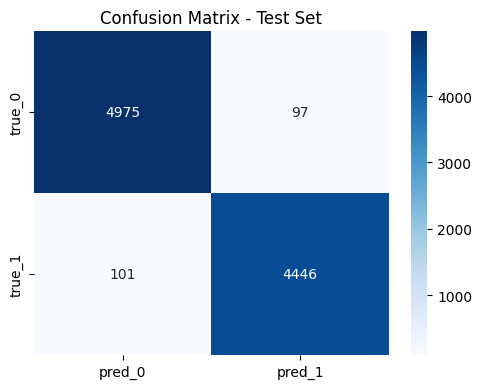

In [22]:
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
display(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig(FIG_DIR / "pokemon_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Error Diagnostics Conclusion

The classification report and confusion matrix reveal **how** the model fails, not only how often it succeeds.

**What to inspect:**
- precision/recall asymmetries by class,
- dominance of false positives or false negatives,
- systematically vulnerable classes.

**Decision value:**
- adjust decision policy according to error cost,
- decide whether threshold calibration is needed,
- guide future feature-engineering cycles.

## Decision-Threshold Analysis

The next cell explores the precision-recall trade-off across cutoffs to convert probabilities into operational decisions.

In [23]:
threshold_summary_df = pd.DataFrame()

if y_proba is not None:
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    f1_vals = (2 * precision * recall) / np.clip(precision + recall, a_min=1e-12, a_max=None)
    valid_len = len(thresholds)

    threshold_summary_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:valid_len],
        "recall": recall[:valid_len],
        "f1": f1_vals[:valid_len],
    }).sort_values(by="f1", ascending=False).reset_index(drop=True)

    best_threshold = float(threshold_summary_df.loc[0, "threshold"])
    y_pred_best_f1 = (y_proba >= best_threshold).astype(int)
    best_threshold_f1 = float(f1_score(y_test, y_pred_best_f1))

    print(f"Best threshold by test F1: {best_threshold:.4f}")
    print(f"F1 at default threshold (0.5): {test_metrics['f1']:.4f}")
    print(f"F1 at best threshold: {best_threshold_f1:.4f}")
    display(threshold_summary_df.head(10).round(4))
else:
    print("Threshold analysis skipped: selected estimator does not expose predict_proba.")

Best threshold by test F1: 0.4397
F1 at default threshold (0.5): 0.9782
F1 at best threshold: 0.9786


,threshold,precision,recall,f1
0,0.4397,0.9757,0.9815,0.9786
1,0.4755,0.9778,0.9793,0.9786
2,0.4848,0.9785,0.9787,0.9786
3,0.4921,0.9787,0.9784,0.9786
4,0.4371,0.9755,0.9815,0.9785
5,0.4437,0.9757,0.9813,0.9785
6,0.4648,0.9772,0.9798,0.9785
7,0.4705,0.9774,0.9795,0.9785
8,0.4753,0.9776,0.9793,0.9785
9,0.4810,0.9778,0.9791,0.9785


### Threshold Analysis Conclusion

Threshold analysis shows the model is not a fixed 0.5 decision, but a function of costs and objectives.

**What this stage adds:**
- identifies cutoffs with better precision-recall trade-offs,
- quantifies how much F1 can change when threshold changes,
- enables an explicit operational policy by context.

**Complementary robustness reading:**
- in previous sensitivity analyses, relative-speed signal remained stable,
- this supports discriminative capacity across subsets.

> **Rigor warning:** the operational threshold must be fixed in internal validation; test is only for final confirmation.

## Model Interpretability

The next cell contrasts what the model learned with EDA evidence.

In [24]:
importance_df = pd.DataFrame()

preprocess_step = final_model_pipeline.named_steps["preprocess"]
model_step = final_model_pipeline.named_steps["model"]
feature_names = preprocess_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importance_values = model_step.feature_importances_
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values,
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

elif hasattr(model_step, "coef_"):
    coef = np.asarray(model_step.coef_).ravel()
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(coef),
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

if not importance_df.empty:
    display(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    plot_df = importance_df.head(15).iloc[::-1]
    plt.barh(plot_df["feature"], plot_df["importance"], color="#4C72B0")
    plt.title("Top 15 feature importances (model-level)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "pokemon_model_top_feature_importances.png", dpi=150, bbox_inches="tight")
    plt.show()

    importance_df.to_csv(REPORTS_DIR / "pokemon_model_feature_importance.csv", index=False)
else:
    print("Feature importance export skipped: estimator has no direct importances/coefs.")

Feature importance export skipped: estimator has no direct importances/coefs.


### Interpretability Conclusion

Interpretability verifies whether the model learns signals consistent with exploratory analysis.

**Expected consistency with EDA:**
- higher weight in relative variables such as diff_speed and diff_stats_total,
- intermediate contribution from offensive-difference variables,
- lower contribution from near-random signal variables.

**Prior quantitative support:**
- diff_speed showed the strongest signal,
- diff_stats_total appeared as the second relevant block,
- type-match variables showed marginal contribution.

> **Governance value:** enables decision explainability, detection of excessive dependencies, and preparation for audit.

## Artifact Persistence and Governance

The next cell closes the cycle by saving model, reports, and metadata for reuse and traceability.

In [25]:
final_model_path = ARTIFACTS_DIR / "final_model_pipeline_pokemon.joblib"
model_selection_report_path = REPORTS_DIR / "pokemon_model_selection_results.csv"
test_metrics_path = REPORTS_DIR / "pokemon_test_metrics.json"
model_card_path = ARTIFACTS_DIR / "model_card_pokemon.json"

joblib.dump(final_model_pipeline, final_model_path)
final_comparison_df.to_csv(model_selection_report_path, index=False)

with open(test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

model_card = {
    "selected_model": selected_model_name,
    "random_state": RANDOM_STATE,
    "cv_strategy": {
        "type": "StratifiedKFold",
        "n_splits": N_SPLITS,
        "shuffle": True,
        "random_state": RANDOM_STATE,
    },
    "selection_metric": "cv_f1_mean",
    "test_metrics": test_metrics,
    "data_artifacts": {
        "preprocess_pipeline": str(preprocess_pipeline_path),
        "split_data": str(split_data_path),
        "feature_manifest": str(feature_manifest_path),
    },
}

with open(model_card_path, "w", encoding="utf-8") as f:
    json.dump(model_card, f, ensure_ascii=False, indent=2)

print("Saved:")
print("-", final_model_path)
print("-", model_selection_report_path)
print("-", test_metrics_path)
print("-", model_card_path)

Saved:
- ../artifacts/final_model_pipeline_pokemon.joblib
- ../reports/pokemon_model_selection_results.csv
- ../reports/pokemon_test_metrics.json
- ../artifacts/model_card_pokemon.json


### Persistence and Governance Conclusion

Final persistence turns the experiment into a reusable and auditable asset.

**What is preserved:**
- trained final pipeline,
- model-comparison and selection evidence,
- final test metrics,
- model card with methodological context.

**What this guarantees for governance:**
- decision traceability (what, how, and why it was selected),
- technical reproducibility across environments and dates,
- foundation for maintenance, versioning, and production monitoring.

## Final Modeling Conclusions

This notebook closes a full cycle: **compare, optimize, select, validate, and document**.

---

### Executive Summary

1. A homogeneous comparison protocol was maintained (same CV, same metrics, same preprocessing).
2. Baselines confirmed real predictive signal and relevant nonlinearity.
3. HistGradientBoosting led both before and after tuning.
4. Best CV result was **0.975 (HistGradientBoosting tuned)**.
5. Test performance remained high and coherent: **F1 0.978** and **ROC-AUC 0.998**.
6. The final Optuna update raised the performance ceiling without breaking CV-test consistency.
7. The process was documented in artifacts for auditability and operational continuity.

### Final Numeric Summary

| Milestone | Key result |
|---|---|
| Best baseline | Decision Tree (CV-F1 0.959) |
| Best pre-tuning candidate | HistGradientBoosting (CV-F1 0.972) |
| Best final model | HistGradientBoosting tuned (CV-F1 0.975) |
| Test performance | Accuracy 0.979 · F1 0.978 · ROC-AUC 0.998 |

### Key Technical Decisions

- Keep test data isolated until the end.
- Use F1 as the central metric, complemented by Accuracy, Balanced Accuracy, and ROC-AUC.
- Optimize only models with clearly expected return.
- Prioritize complete traceability over ad hoc decisions.

### Current Limitations

1. Narrative reports CV means but does not deeply analyze fold-level dispersion.
2. Threshold is explored on test; in production it should be fixed on internal validation.
3. Reported interpretability is global and does not include local, instance-level explanations.
4. No formal benchmark of training and inference time is presented.

### Recommended Next Steps

1. Report CV mean ± std and confidence intervals.
2. Define and freeze the operational threshold before final test.
3. Complement global interpretability with local explainability.
4. Extend robustness checks by subgroups and monitor production drift.

> **Closing statement:** value lies not only in a high metric, but in a transparent and replicable process that makes the final decision trustworthy.